In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

! pip install xgboost

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

In [4]:
df = pd.read_csv('/content/drive/MyDrive/final project/Diseases_and_Symptoms_Data.csv')

In [5]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.columns

Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='object', length=378)

In [7]:
X = df.drop('diseases', axis = 1)
y = df['diseases']

In [8]:
len(y.unique())

773

In [9]:
y = y.str.lower()
y = y.str.strip()

In [10]:
len(y.unique())

773

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 377 entries, anxiety and nervousness to neck weakness
dtypes: int64(377)
memory usage: 710.3 MB


In [12]:
# converting data type 'int64' to 'int8' to reduce the memory usages
X = X.astype({col: "int8" for col in df.select_dtypes("int64").columns})

In [13]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 377 entries, anxiety and nervousness to neck weakness
dtypes: int8(377)
memory usage: 88.8 MB


# Train Test Split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [16]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((172861, 377), (74084, 377), (172861,), (74084,))

In [17]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)

In [18]:
# Find labels that exist in training set
# Convert valid_labels to a set of strings
valid_labels = np.array(list(map(str, le.classes_)), dtype=object)

In [19]:
# valid_labels = np.array(list(valid_labels)).astype('int16')

In [20]:
print("y_test dtype:", y_test.dtype)
print("valid_labels dtype:", type(next(iter(valid_labels))))

y_test dtype: object
valid_labels dtype: <class 'str'>


In [21]:
# Mask for valid test labels
mask = np.isin(y_test, valid_labels)

In [22]:
mask

array([ True,  True,  True, ...,  True,  True,  True])

In [23]:
np.unique(mask)

array([False,  True])

In [24]:
np.unique(mask)

array([False,  True])

In [25]:
# Filter X_test and y_test
X_test = X_test[mask]
y_test_filtered = y_test[mask]

In [26]:
# Encode only valid test labels
y_test = le.transform(y_test_filtered)

In [27]:
y_test

array([120, 706, 544, ..., 610, 454, 649])

In [28]:
y_train.dtype, y_test.dtype

(dtype('int64'), dtype('int64'))

In [29]:
y_train = y_train.astype('int16')
y_test = y_test.astype('int16')

# Xgboost

In [32]:
model = xgb.XGBClassifier(
    tree_method = "hist",
    device = "cuda:0",
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_lambda = 2,
    reg_alpha=1,
    early_stopping_rounds=10,
    eval_metric = 'mlogloss',
    random_state=42
    )

In [33]:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-mlogloss:5.12497
[1]	validation_0-mlogloss:4.44232
[2]	validation_0-mlogloss:4.00643
[3]	validation_0-mlogloss:3.69173
[4]	validation_0-mlogloss:3.44275
[5]	validation_0-mlogloss:3.23963
[6]	validation_0-mlogloss:3.06528
[7]	validation_0-mlogloss:2.91363
[8]	validation_0-mlogloss:2.78049
[9]	validation_0-mlogloss:2.66176
[10]	validation_0-mlogloss:2.55367
[11]	validation_0-mlogloss:2.45528
[12]	validation_0-mlogloss:2.36483
[13]	validation_0-mlogloss:2.28177
[14]	validation_0-mlogloss:2.20443
[15]	validation_0-mlogloss:2.13270
[16]	validation_0-mlogloss:2.06530
[17]	validation_0-mlogloss:2.00207
[18]	validation_0-mlogloss:1.94300
[19]	validation_0-mlogloss:1.88693
[20]	validation_0-mlogloss:1.83399
[21]	validation_0-mlogloss:1.78401
[22]	validation_0-mlogloss:1.73662
[23]	validation_0-mlogloss:1.69177
[24]	validation_0-mlogloss:1.64912
[25]	validation_0-mlogloss:1.60843
[26]	validation_0-mlogloss:1.56948
[27]	validation_0-mlogloss:1.53228
[28]	validation_0-mlogloss:1.4

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda:0', early_stopping_rounds=10,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_class=765, num_parallel_tree=None, ...)

In [34]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:18:01] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [36]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8549808972230097
Precision: 0.8609774872294841
Recall: 0.8549808972230097
F1-score: 0.8552550278160341


In [59]:
import pickle

pickle.dump(model, open('/content/drive/MyDrive/medication_ai/models/xgboost/xgboost.pkl', 'wb'))

In [39]:
from joblib import dump, load

In [60]:
xgboost = load('/content/drive/MyDrive/medication_ai/models/xgboost/xgboost.pkl')

In [61]:
dump(xgboost, '/content/drive/MyDrive/medication_ai/models/xgboost/com_xgboost.pkl', compress=3)

['/content/drive/MyDrive/medication_ai/models/xgboost/com_xgboost.pkl']

In [42]:
train_predict = model.predict(X_train)
accuracy = accuracy_score(y_train, train_predict)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8957717472420037


In [43]:
# Report the best score on the best iteration
print(f'Best score {model.best_score}, Best iteration {model.best_iteration}')

Best score 0.4149902507838714, Best iteration 249


In [62]:
pickle.dump(le, open('/content/drive/MyDrive/medication_ai/models/xgboost/LabelEncoder.pkl', 'wb'))

In [45]:
from joblib import dump, load

In [63]:
with open('/content/drive/MyDrive/medication_ai/models/xgboost/com_xgboost.pkl', 'rb') as p_model_file:
  p_model = load(p_model_file)

In [64]:
symptom_list = [i for i in X_train.columns]

In [65]:
symptom_list

['anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat',
 'throat feels tight',
 'difficulty in swallowing',
 'skin swelling',
 'retention of urine',
 'groin mass',
 'leg pain',
 'hip pain',
 'suprapubic pain',
 'blood in stool',
 'lack of growth',
 'emotional symptoms',
 'elbow weakness',
 'back weakness',
 'pus in sputum',
 'symptoms of the scrotum and testes',
 'swelling of scrotum',
 'pain in testicles',
 'flatulence',
 'pus draining from ear',
 'jaundice',
 'mass in scrotum',
 'white discharge from eye',
 'irritable infant',
 'abusing alcohol',
 'fainting',
 'hostile behavior',
 'drug abuse',
 'sharp abdominal pain',
 'feeling 

In [49]:
# 3️⃣ Create a dictionary with all symptoms set to 0
user_input = {symptom: 0 for symptom in symptom_list}

# 4️⃣ Ask user to enter the symptoms they have
print("\n✅ Available Symptoms:", ", ".join(symptom_list))
selected_symptoms = input("\n🔹 Enter the symptoms you have (comma-separated): ").lower().split(",")

# 5️⃣ Update selected symptoms to 1
for symptom in selected_symptoms:
    symptom = symptom.strip()  # Remove spaces
    if symptom in user_input:
        user_input[symptom] = 1  # Mark as present
    else:
        print(f"⚠️ Warning: '{symptom}' is not a recognized symptom.")


✅ Available Symptoms: anxiety and nervousness, depression, shortness of breath, depressive or psychotic symptoms, sharp chest pain, dizziness, insomnia, abnormal involuntary movements, chest tightness, palpitations, irregular heartbeat, breathing fast, hoarse voice, sore throat, difficulty speaking, cough, nasal congestion, throat swelling, diminished hearing, lump in throat, throat feels tight, difficulty in swallowing, skin swelling, retention of urine, groin mass, leg pain, hip pain, suprapubic pain, blood in stool, lack of growth, emotional symptoms, elbow weakness, back weakness, pus in sputum, symptoms of the scrotum and testes, swelling of scrotum, pain in testicles, flatulence, pus draining from ear, jaundice, mass in scrotum, white discharge from eye, irritable infant, abusing alcohol, fainting, hostile behavior, drug abuse, sharp abdominal pain, feeling ill, vomiting, headache, nausea, diarrhea, vaginal itching, vaginal dryness, painful urination, involuntary urination, pain

In [50]:
input_data = pd.DataFrame([user_input])

In [51]:
perdicted_disease = p_model.predict(input_data)

In [66]:
with open('/content/drive/MyDrive/medication_ai/models/xgboost/LabelEncoder.pkl', 'rb') as p_model_file:
  le_model = pickle.load(p_model_file)

In [53]:
predicted_disease = le_model.inverse_transform(perdicted_disease)

In [54]:
print(f"\n🔍 Based on the symptoms, the predicted disease is: **{predicted_disease}**")


🔍 Based on the symptoms, the predicted disease is: **['breast cyst']**


In [55]:
# ROC Curve (for multi-class classification)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

In [58]:
y_prob = model.predict_proba(X_test)
print(y_prob)

[[5.4190717e-05 4.7151359e-05 6.5174085e-05 ... 5.7268040e-05
  5.0928884e-05 5.2610372e-05]
 [5.0330510e-07 4.3792548e-07 6.0913629e-07 ... 5.3188626e-07
  4.7300983e-07 4.8862694e-07]
 [6.1478936e-06 5.3492840e-06 7.3939464e-06 ... 2.4993642e-04
  5.7778407e-06 5.9686049e-06]
 ...
 [2.0437440e-06 1.7782605e-06 2.4579672e-06 ... 2.1598019e-06
  1.8166493e-05 1.9841409e-06]
 [2.0470645e-07 1.7811513e-07 2.4619629e-07 ... 2.1633107e-07
  1.9238480e-07 1.9873666e-07]
 [2.9103647e-05 2.5323070e-05 3.5002369e-05 ... 3.0756350e-05
  1.9016989e-04 2.8254883e-05]]


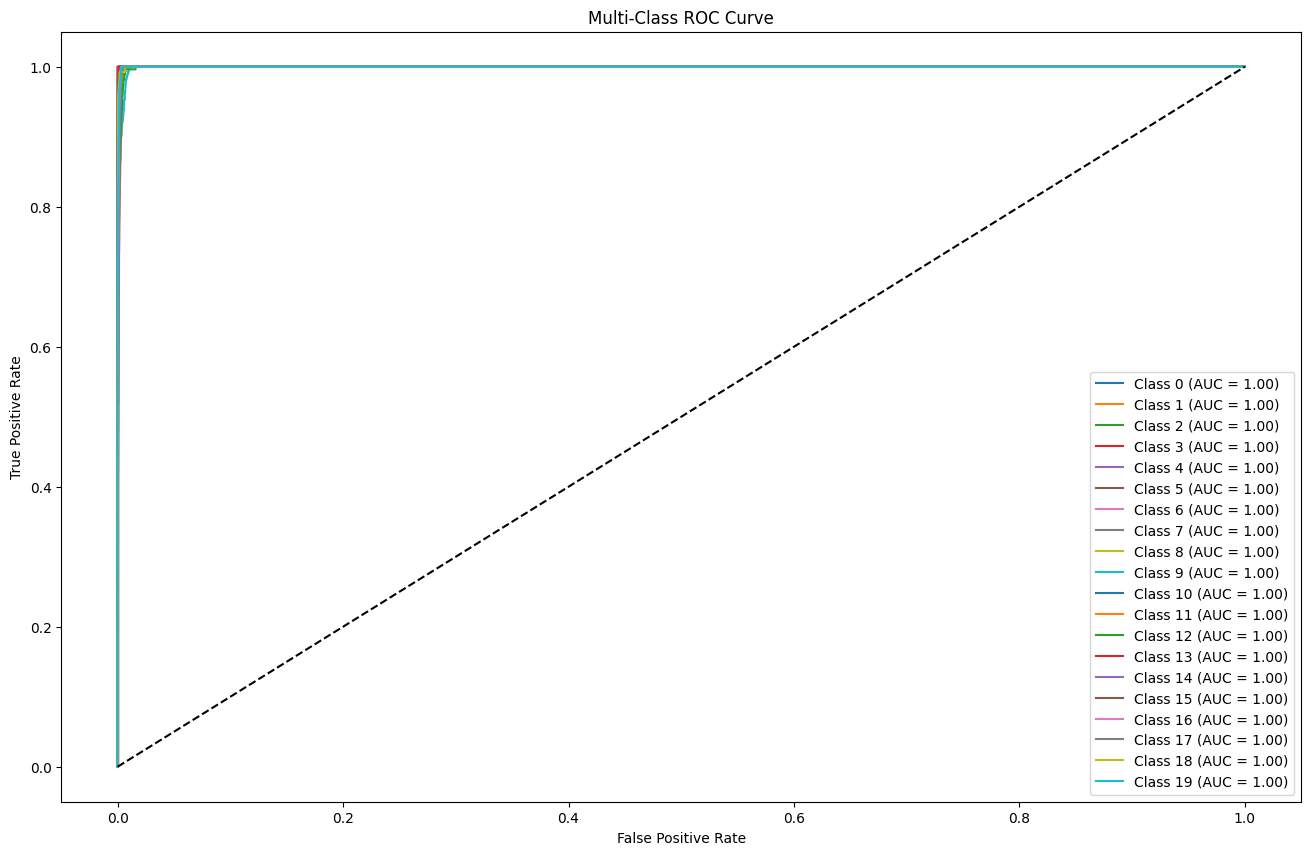

In [57]:
# ROC Curve (for multi-class classification)
n_classes = len(np.unique(y_test))
if n_classes > 2:
    plt.figure(figsize=(16, 10))
    for i in range(min(20, y_test_bin.shape[1])):  # Plot only 10 classes
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multi-Class ROC Curve")
    plt.legend()
    plt.savefig("roc_curve.png")
    plt.show()
